Target Guided Ordinal Encoding

It is a technique used to encode categorical variables based on their relationship with the target variable. This encoding technique is useful when we have a categorical variable with a large number of unique categories, and we want to use this variable as a feature in our machine learning model.

In Target Guided Ordinal Encoding, we replace each category in the categorical variable with a numerical value based on the mean or median of the target variable for that category. This creates a monotonic relationship between the categorical variable and the target variable, which can improve the predictive power of our model.

In [1]:
import pandas as pd
df=pd.DataFrame({
    'city':['New York','London','Paris','Tokyo','New York','Paris'],
    'price':[200,150,300,250,180,320]
})

In [2]:
df

,city,price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [4]:
mean_price=df.groupby('city')['price'].mean().to_dict()

In [5]:
mean_price

{'London': 150.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [6]:
df['mean_encoder']=df['city'].map(mean_price)

In [7]:
df

,city,price,mean_encoder
0,New York,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0


In [12]:
pd.concat([df['mean_encoder'], df['price']], axis=1)


,mean_encoder,price
0,190.0,200
1,150.0,150
2,310.0,300
3,250.0,250
4,190.0,180
5,310.0,320


In [19]:
import seaborn as sns
tips=sns.load_dataset('tips')


In [20]:
mean_bill = tips.groupby('time')['total_bill'].mean().to_dict()


C:\Users\amitk\AppData\Local\Temp\ipykernel_4964\1555664664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bill = tips.groupby('time')['total_bill'].mean().to_dict()


In [23]:
tips['mean_encoder']=tips['time'].map(mean_bill)

In [24]:
tips

,total_bill,tip,sex,smoker,day,time,size,mean_encoder
0,16.99,1.01,Female,No,Sun,Dinner,2,20.797159
1,10.34,1.66,Male,No,Sun,Dinner,3,20.797159
2,21.01,3.50,Male,No,Sun,Dinner,3,20.797159
3,23.68,3.31,Male,No,Sun,Dinner,2,20.797159
4,24.59,3.61,Female,No,Sun,Dinner,4,20.797159
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.797159
240,27.18,2.00,Female,Yes,Sat,Dinner,2,20.797159
241,22.67,2.00,Male,Yes,Sat,Dinner,2,20.797159
242,17.82,1.75,Male,No,Sat,Dinner,2,20.797159


In [25]:
pd.concat([tips['mean_encoder'], tips['time']], axis=1)

,mean_encoder,time
0,20.797159,Dinner
1,20.797159,Dinner
2,20.797159,Dinner
3,20.797159,Dinner
4,20.797159,Dinner
...,...,...
239,20.797159,Dinner
240,20.797159,Dinner
241,20.797159,Dinner
242,20.797159,Dinner


In [2]:
import seaborn as sns
titanic=sns.load_dataset("titanic")

In [3]:
mean_age=titanic.groupby('who')['age'].mean().to_dict()

In [4]:
mean_age

{'child': 6.369518072289156, 'man': 33.17312348668281, 'woman': 32.0}

In [8]:
titanic['mean_encoder']=titanic['who'].map(mean_age)

In [ ]:
import pandas as pd
pd.concat([titanic['mean_encoder'],titanic['who']],axis=1)

,mean_encoder,who
0,33.173123,man
1,32.000000,woman
2,32.000000,woman
3,32.000000,woman
4,33.173123,man
...,...,...
886,33.173123,man
887,32.000000,woman
888,32.000000,woman
889,33.173123,man


In [16]:
import seaborn as sns
data=sns.load_dataset('penguins')

In [15]:
import pandas as pd

In [17]:
data.isnull()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [38]:
data['bill_depth_MM']=data['bill_depth_mm'].fillna(0)

In [39]:
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_depth_MM,mean_encoder
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,18.7,17.891071
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,17.4,16.425455
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,18.0,16.425455
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,19.3,16.425455


In [40]:
sex_encoder=data.groupby('sex')['bill_depth_MM'].mean().to_dict()

In [41]:
sex_encoder

{'Female': 16.425454545454546, 'Male': 17.89107142857143}

In [42]:
data['mean_encoder']=data['sex'].map(sex_encoder)

In [43]:
pd.concat([data['mean_encoder'],data['sex']],axis=1)

,mean_encoder,sex
0,17.891071,Male
1,16.425455,Female
2,16.425455,Female
3,NaN,NaN
4,16.425455,Female
...,...,...
339,NaN,NaN
340,16.425455,Female
341,17.891071,Male
342,16.425455,Female


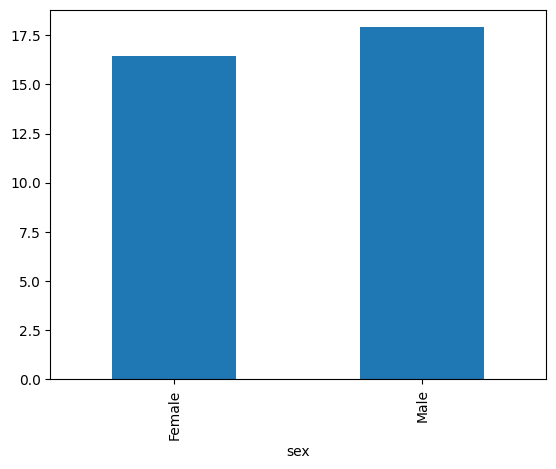

In [51]:
import matplotlib.pyplot as plt
data.groupby('sex')['mean_encoder'].mean().plot(kind='bar')
plt.show()


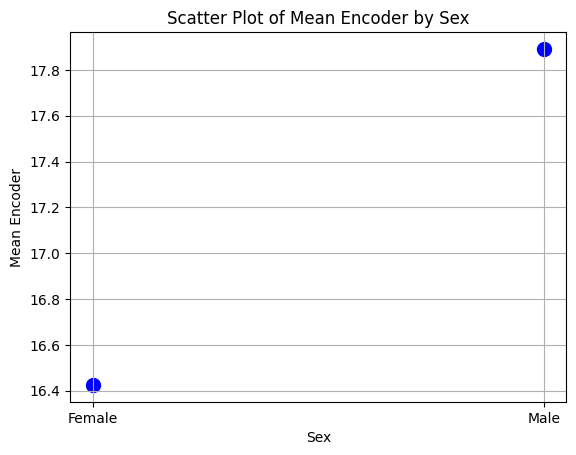

In [52]:
import matplotlib.pyplot as plt

# Group and calculate mean
grouped = data.groupby('sex')['mean_encoder'].mean()

# Create scatter plot
plt.scatter(grouped.index, grouped.values, color='blue', s=100)  # s = marker size
plt.xlabel('Sex')
plt.ylabel('Mean Encoder')
plt.title('Scatter Plot of Mean Encoder by Sex')
plt.grid(True)
plt.show()
